In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xs
import cartopy.crs as ccrs       
import cartopy.feature as cfeature

In [8]:
Maria_data = ('~/Desktop/ISAT-Semester-Project/Hurricane Maria/table1_best_track.csv')
ds = pd.read_csv(Maria_data, na_values = [-999, -9999],)

In [9]:
ds

,Date/Time (UTC),Latitude (°N),Longitude (°W),Pressure (mb),Wind Speed (kt),Stage,Notes
0,16/1200,12.2,49.7,1006.0,30.0,tropical depression,NaN
1,16/1800,12.2,51.7,1004.0,40.0,tropical storm,NaN
2,17/0000,12.4,53.1,1002.0,45.0,tropical storm,NaN
3,17/0600,12.8,54.4,994.0,55.0,tropical storm,NaN
4,17/1200,13.3,55.7,990.0,60.0,tropical storm,NaN
...,...,...,...,...,...,...,...
64,01/1800,46.5,31.0,1003.0,45.0,extratropical,NaN
65,02/0000,47.5,26.5,1005.0,40.0,extratropical,NaN
66,02/0600,48.0,22.0,1012.0,40.0,extratropical,NaN
67,02/1200,48.0,17.0,1016.0,30.0,extratropical,NaN


In [10]:
columns_to_keep = ['Latitude (°N)','Longitude (°W)']
ds = ds[columns_to_keep]
ds

,Latitude (°N),Longitude (°W)
0,12.2,49.7
1,12.2,51.7
2,12.4,53.1
3,12.8,54.4
4,13.3,55.7
...,...,...
64,46.5,31.0
65,47.5,26.5
66,48.0,22.0
67,48.0,17.0


/Users/jah/anaconda3/envs/ISAT_420/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jah/anaconda3/envs/ISAT_420/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jah/anaconda3/envs/ISAT_420/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


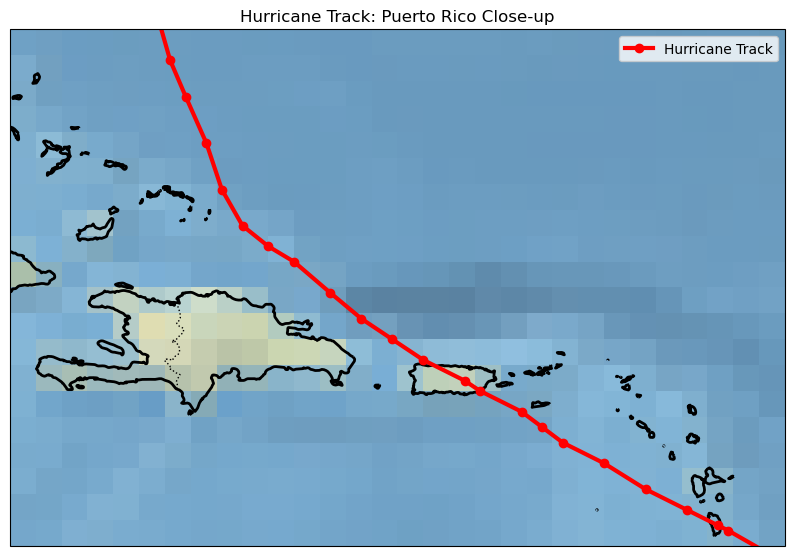

In [13]:
ds_clean = ds.dropna()

# 2. Create the map
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Add Satellite-style background and detailed features
ax.stock_img() 
ax.add_feature(cfeature.COASTLINE, linewidth=2)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# 4. ZOOM IN ON PUERTO RICO
# Format: [West Longitude, East Longitude, South Latitude, North Latitude]
# Note: Use negative values for West longitude
ax.set_extent([-75.0, -60.0, 15.0, 25.0], crs=ccrs.PlateCarree())

# 5. Plot the hurricane track
# We multiply Longitude by -1 because your data uses positive values for '°W'
plt.plot(-ds_clean['Longitude (°W)'], ds_clean['Latitude (°N)'],
         color='red', linewidth=3, marker='o', markersize=6,
         transform=ccrs.Geodetic(), label='Hurricane Track')

plt.title('Hurricane Track: Puerto Rico Close-up')
plt.legend()
plt.show()